# **MainQuest: Credit Card Fraud Detection**

<br>

## **I. 프로젝트 개요**

---

### **가이드라인 (Notion)**

#### **메인퀘스트 : Credit Card Fraud Detection**

- 데이터 사이언티스트로써, 다음 [캐글 Competition](https://www.kaggle.com/t/9106436abdaa42dd9f90ba75819f2296) 으로 이동하여

- 신용카드 사기 검출을 분류하여 고객이 구매하지 않은 상품에 대해 요금이 청구되지 않도록 합시다!

<br>

#### **대회 Overview :**

- 예측할 값(y): `Class` (0:Not fraud, 1:fraud)

- 모델 평가 지표 : `f1-score`

- 제출 형식
    - 1. Code탭에 New NoteBook으로 새 노트북을 만들어 프로젝트 수행 후 코드 쉐어로 제출
    - 2. 예측한 결과물 파일(`.csv`) 메인 우측 상단에 Submit Prediction 버튼을 눌러 제출

<br>

#### **퀘스트 평가 기준:**

- 데이터 이해 및 탐색: Class의 균형과 데이터의 분포와 특성을 시각화를 통해서 파악했는가?

- 모델 선택 및 비교: 3개 이상의 모델을 학습시키고 성능을 비교했는가?

- 레이블 불균형을 처리하기 위한 기법을 시도했는가?

- 여러 모델을 앙상블을 통해 결합하여 성능을 비교했는가?

- Ridge/Lasso 등의 규제 추가, 트리 기반 모델의 깊이/학습률 등 하이퍼파라미터를 조정하여 성능 향상을 시도했는가?

<br>

### **Kaggle Competition Overview**

#### **Mission**

Kaggle의 신용카드 데이터 셋을 활용해서 신용카드 사기 검출을 분류하여 고객이 구매하지 않은 상품에 대해 요금이 청구되지 않도록 신용카드 회사가 신용카드 사기 거래를 식별하는 미션을 수행하는 프로젝트입니다.

<br>

#### **[분류] 신용카드 사기 거래를 탐지**

- 예측할 값(y): Class (0:Not fraud, 1:fraud)

- 평가: F1-Score 평가지표

- 제출 형식
    1. Code탭에 New NoteBook으로 새 노트북을 만들어 프로젝트 수행 후 코드 쉐어로 제출
    2. 예측한 결과물 파일(.csv) 메인 우측 상단에 Submit Prediction 버튼을 눌러 제출

<br>

#### **루브릭**

- 데이터 이해 및 탐색: Class의 균형과 데이터의 분포와 특성을 시각화를 통해서 파악했는가?

- 모델 선택 및 비교: 3개 이상의 모델을 학습시키고 성능을 비교했는가?

- 레이블 불균형을 처리하기 위한 기법을 시도했는가?

- 여러 모델을 앙상블을 통해 결합하여 성능을 비교했는가?

- Ridge/Lasso 등의 규제 추가, 트리 기반 모델의 깊이/학습률 등 하이퍼파라미터를 조정하여 성능 향상을 시도했는가?

<br><br>


## **II. 프로젝트 수행**

---

### **0. 환경 세팅 (버전 고정)**

In [ ]:
# 라이브러리 버전 고정

In [ ]:
!pip uninstall -y xgboost lightgbm

Found existing installation: xgboost 3.1.3
Uninstalling xgboost-3.1.3:
  Successfully uninstalled xgboost-3.1.3
Found existing installation: lightgbm 4.6.0
Uninstalling lightgbm-4.6.0:
  Successfully uninstalled lightgbm-4.6.0


In [ ]:
!pip install xgboost==1.5.0 lightgbm==3.3.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.5/173.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.8 MB/s eta 0:00:00


In [ ]:
!pip install hyperopt

In [ ]:
# 필요 라이브러리 로드

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    precision_recall_curve, average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import lightgbm as lgb
import xgboost as xgb

plt.rcParams["figure.figsize"] = (10, 5)

<br>

### **1. 데이터 로드 & 무결성 체크**

#### **데이터 로드**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train_df = pd.read_csv("/content/drive/MyDrive/DS_8th/05_머신러닝 활용 다양한 데이터 다루기/34일차_2 4(수)/data/train.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/DS_8th/05_머신러닝 활용 다양한 데이터 다루기/34일차_2 4(수)/data/test.csv")

In [ ]:
print(train_df.shape, test_df.shape)
display(train_df.head())
train_df.info()
test_df.info()

(170883, 32) (113923, 31)


,id,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170883 entries, 0 to 170882
Data columns (total 32 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      170883 non-null  int64  
 1   Time    170883 non-null  float64
 2   V1      170883 non-null  float64
 3   V2      170883 non-null  float64
 4   V3      170883 non-null  float64
 5   V4      170883 non-null  float64
 6   V5      170883 non-null  float64
 7   V6      170883 non-null  float64
 8   V7      170883 non-null  float64
 9   V8      170883 non-null  float64
 10  V9      170883 non-null  float64
 11  V10     170883 non-null  float64
 12  V11     170883 non-null  float64
 13  V12     170883 non-null  float64
 14  V13     170883 non-null  float64
 15  V14     170883 non-null  float64
 16  V15     170883 non-null  float64
 17  V16     170883 non-null  float64
 18  V17     170883 non-null  float64
 19  V18     170883 non-null  float64
 20  V19     170883 non-null  float64
 21  V20     17

<br>

#### **기본 무결성 체크**

In [ ]:
# 1) 결측치

In [ ]:
print("Train missing:", train_df.isna().sum().sum())
print("Test missing :", test_df.isna().sum().sum())

Train missing: 0
Test missing : 0


In [ ]:
# 2) id 유일성

In [ ]:
print("Train id unique:", train_df["id"].is_unique)
print("Test id unique :", test_df["id"].is_unique)

Train id unique: True
Test id unique : True


In [ ]:
# 3) 컬럼 일치 체크 (train은 Class가 추가로 있음)

In [ ]:
train_cols = set(train_df.columns)
test_cols  = set(test_df.columns)

print("Train - Test:", train_cols - test_cols)  # 보통 {'Class'}
print("Test - Train:", test_cols - train_cols)  # 보통 빈 집합

Train - Test: {'Class'}
Test - Train: set()


<br>

### **2. 타깃 불균형 진단**

In [ ]:
# Class 분포 확인

Class counts:
 Class
0    170523
1       360
Name: count, dtype: int64

Class ratio:
 Class
0    0.997893
1    0.002107
Name: proportion, dtype: float64


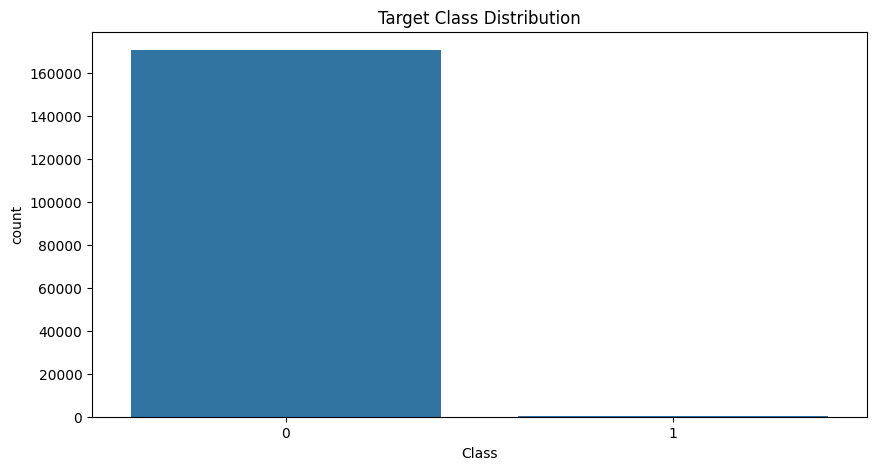

In [ ]:
class_counts = train_df["Class"].value_counts()
class_ratio = train_df["Class"].value_counts(normalize=True)

print("Class counts:\n", class_counts)
print("\nClass ratio:\n", class_ratio)

fig, ax = plt.subplots()
sns.countplot(x="Class", data=train_df, ax=ax)
ax.set_title("Target Class Distribution")
plt.show()

In [ ]:
# 극단적 불균형이라 로그 스케일로도 확인

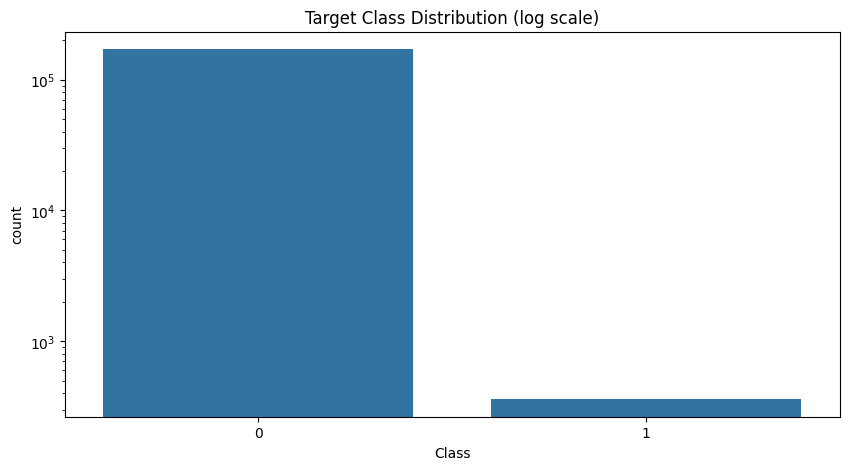

In [ ]:
fig, ax = plt.subplots()
sns.countplot(x="Class", data=train_df, ax=ax)
ax.set_yscale("log")
ax.set_title("Target Class Distribution (log scale)")
plt.show()

- 사기(1) 비율이 약 0.17%로 매우 희소하여, 정확도는 무의미하고

- F1/PR-AUC 중심으로 평가해야 함.

<br>

### **3. 핵심 EDA**

#### **1) Amount/Time 중심 + 클래스별 비교**

In [ ]:
# Amount / Time 분포 (전체 + 클래스별)

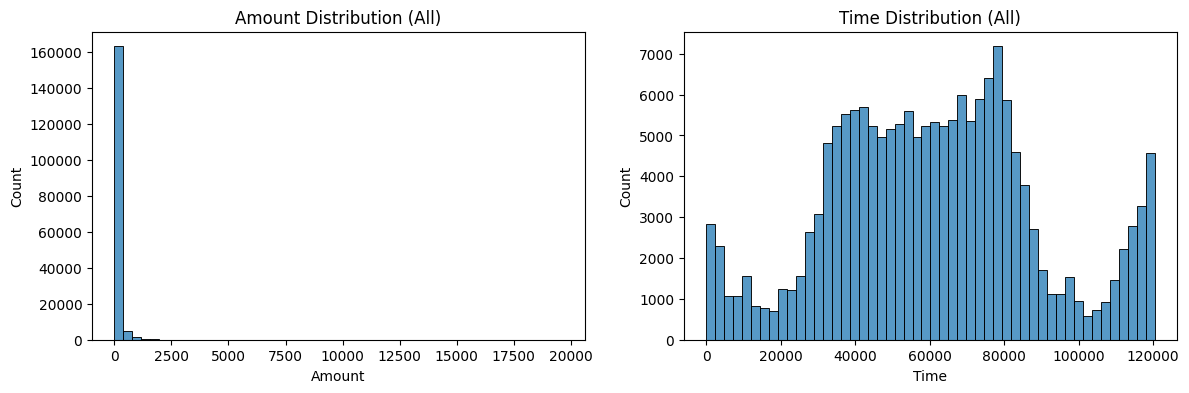

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(train_df["Amount"], bins=50, ax=axes[0])
axes[0].set_title("Amount Distribution (All)")

sns.histplot(train_df["Time"], bins=50, ax=axes[1])
axes[1].set_title("Time Distribution (All)")

plt.show()

In [ ]:
# 클래스별 Amount 분포(사기는 너무 적으니 KDE/로그도 같이 보는 게 유리)

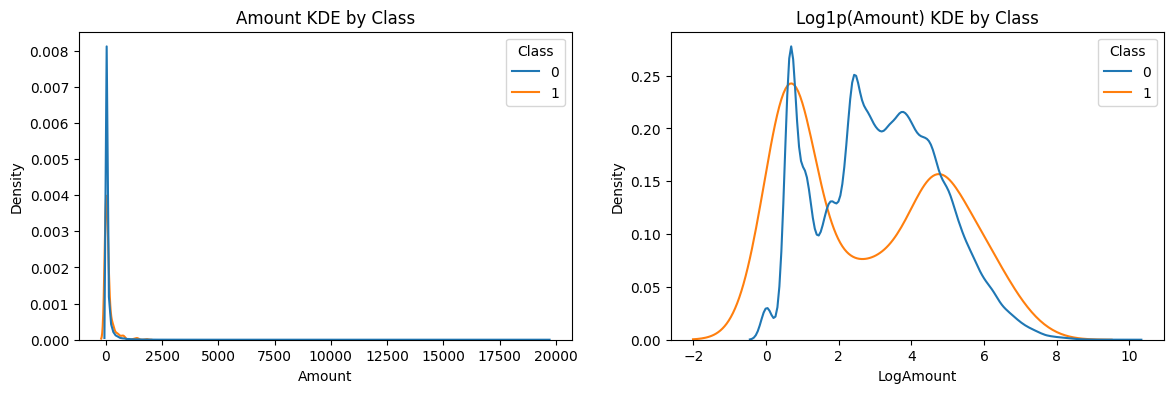

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.kdeplot(data=train_df, x="Amount", hue="Class", ax=axes[0], common_norm=False)
axes[0].set_title("Amount KDE by Class")

train_df["LogAmount"] = np.log1p(train_df["Amount"])
sns.kdeplot(data=train_df, x="LogAmount", hue="Class", ax=axes[1], common_norm=False)
axes[1].set_title("Log1p(Amount) KDE by Class")

plt.show()

In [ ]:
# Time의 일중 주기성 파생 확인
# 2일치 거래이므로 '하루(86400초)' 주기 특징을 줄 수 있음.

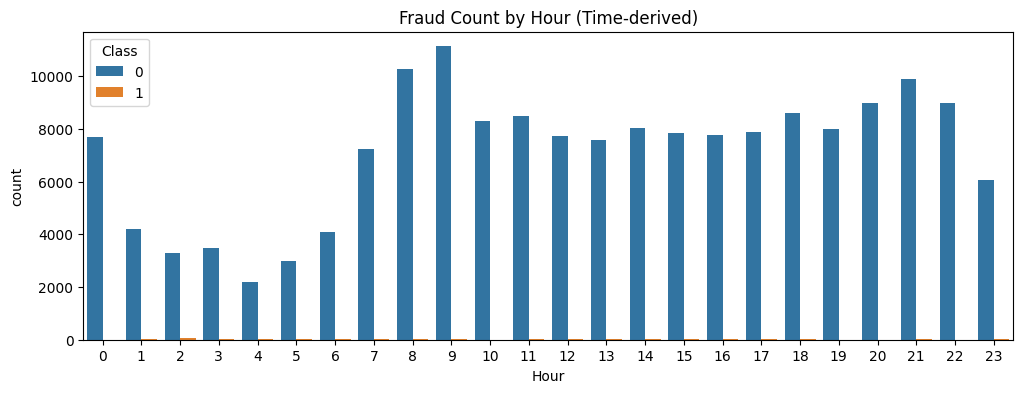

In [ ]:
train_df["Time_in_day"] = train_df["Time"] % 86400
train_df["Hour"] = (train_df["Time_in_day"] // 3600).astype(int)

fig, ax = plt.subplots(figsize=(12,4))
sns.countplot(x="Hour", hue="Class", data=train_df, ax=ax)
ax.set_title("Fraud Count by Hour (Time-derived)")
plt.show()

<br>

#### **2) Train vs Test 분포 차이 진단**

##### **2-1) Amount / Time 분포 비교**

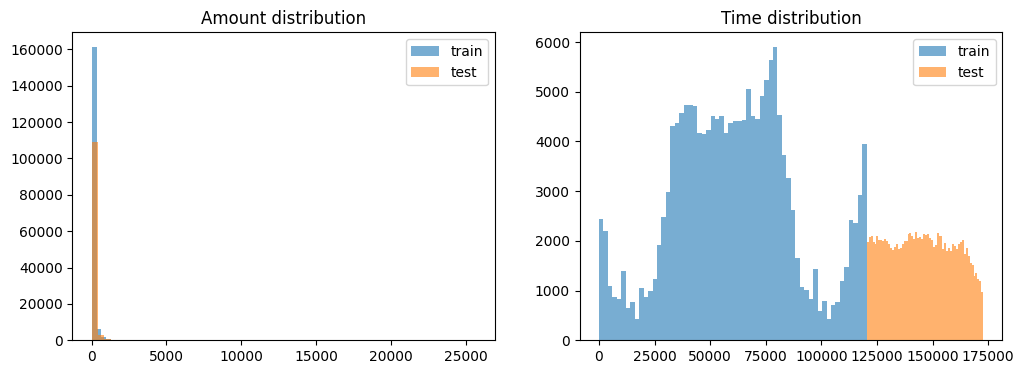

In [4]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].hist(train_df["Amount"], bins=60, alpha=0.6, label="train")
ax[0].hist(test_df["Amount"], bins=60, alpha=0.6, label="test")
ax[0].set_title("Amount distribution"); ax[0].legend()

ax[1].hist(train_df["Time"], bins=60, alpha=0.6, label="train")
ax[1].hist(test_df["Time"], bins=60, alpha=0.6, label="test")
ax[1].set_title("Time distribution"); ax[1].legend()
plt.show()

<br>

##### **2-2) Shift score(KS 통계)로 “차이 큰 피처” 랭킹**

In [7]:
from scipy.stats import ks_2samp

features = [c for c in train_df.columns if c not in ["Class"]]
ks_rows = []
for c in features:
    ks = ks_2samp(train_df[c].values, test_df[c].values).statistic
    ks_rows.append((c, ks))

ks_df = pd.DataFrame(ks_rows, columns=["feature","ks"]).sort_values("ks", ascending=False)
display(ks_df.head(15))

,feature,ks
0,id,1.000000
1,Time,0.999994
4,V3,0.461377
2,V1,0.358373
29,V28,0.302515
26,V25,0.258139
16,V15,0.219840
6,V5,0.209931
12,V11,0.189865
23,V22,0.187236


<br>

#### **3) Fraud(양성)과의 관계 확인 (Amount/Time)**

##### **3-1) Amount 로그 변환 필요성 확인**

/tmp/ipython-input-1892542959.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([train_tmp.loc[train_tmp.Class==0, "Amount_log1p"],


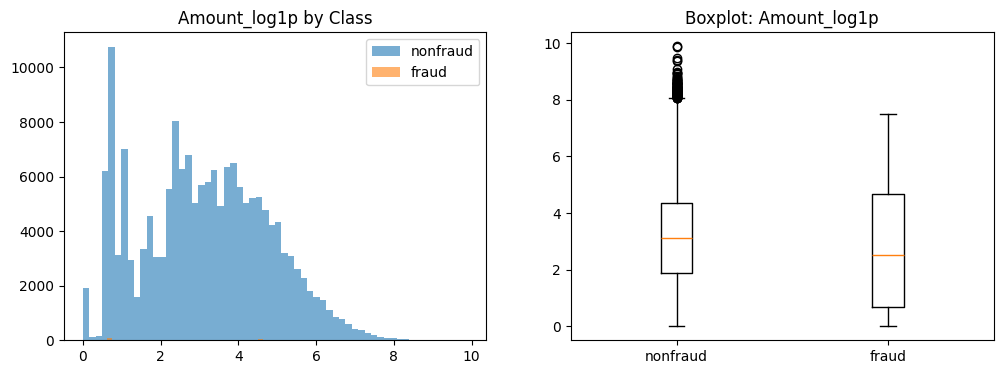

In [9]:
train_tmp = train_df.copy()
train_tmp["Amount_log1p"] = np.log1p(train_tmp["Amount"])

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].hist(train_tmp.loc[train_tmp.Class==0, "Amount_log1p"], bins=60, alpha=0.6, label="nonfraud")
ax[0].hist(train_tmp.loc[train_tmp.Class==1, "Amount_log1p"], bins=60, alpha=0.6, label="fraud")
ax[0].set_title("Amount_log1p by Class"); ax[0].legend()

ax[1].boxplot([train_tmp.loc[train_tmp.Class==0, "Amount_log1p"],
               train_tmp.loc[train_tmp.Class==1, "Amount_log1p"]],
              labels=["nonfraud","fraud"])
ax[1].set_title("Boxplot: Amount_log1p")
plt.show()

<br>

##### **3-2) Time → hour/day 파생 후 fraud rate 보기**

In [10]:
tmp = train_df.copy()
tmp["hour"] = (tmp["Time"] // 3600) % 24
tmp["day"]  = (tmp["Time"] // 86400)

hour_stats = tmp.groupby("hour")["Class"].agg(["count","sum"])
hour_stats["fraud_rate"] = hour_stats["sum"] / hour_stats["count"]
display(hour_stats.sort_values("fraud_rate", ascending=False).head(10))

day_stats = tmp.groupby("day")["Class"].agg(["count","sum"])
day_stats["fraud_rate"] = day_stats["sum"] / day_stats["count"]
display(day_stats)

,count,sum,fraud_rate
hour,,,
2.0,3328,57,0.017127
4.0,2209,23,0.010412
11.0,8517,43,0.005049
3.0,3492,17,0.004868
5.0,2990,11,0.003679
7.0,7243,23,0.003175
23.0,6082,17,0.002795
1.0,4220,10,0.002370
6.0,4101,9,0.002195


,count,sum,fraud_rate
day,,,
0.0,144786,281,0.001941
1.0,26097,79,0.003027


<br>

### **4. 전처리 & 피처 셋 구성**

In [ ]:
# 학습용 feature 구성
# id는 식별자라 feature에서 제외
# Time/Amount는 사용
# LogAmount, Time_in_day, Hour도 사용(효과 있으면 유지)

In [ ]:
feature_cols = [c for c in train_df.columns if c not in ["Class", "id"]]

X = train_df[feature_cols].copy()
y = train_df["Class"].copy()

In [ ]:
# 테스트도 동일 feature로 맞추기
test_id = test_df["id"].copy()

# 테스트도 동일 feature로 맞추기
test_id = test_df["id"].copy()

# test에도 동일 파생 생성
test_df["LogAmount"] = np.log1p(test_df["Amount"])
test_df["Time_in_day"] = test_df["Time"] % 86400
test_df["Hour"] = (test_df["Time_in_day"] // 3600).astype(int)

X_test = test_df[feature_cols].copy()

print("X:", X.shape, "X_test:", X_test.shape)

X: (170883, 33) X_test: (113923, 33)


<br>

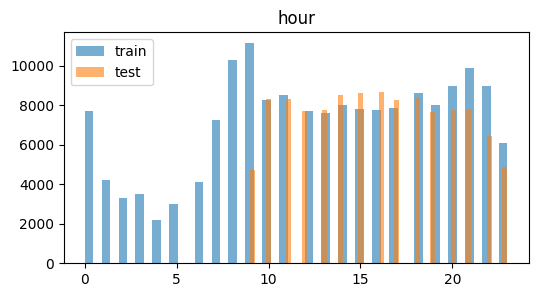

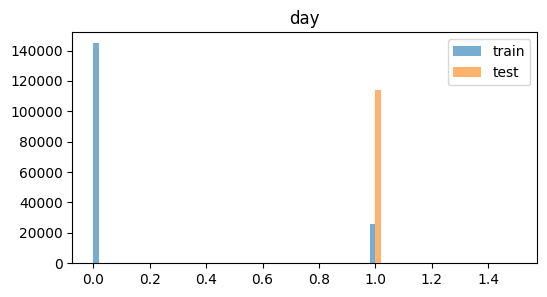

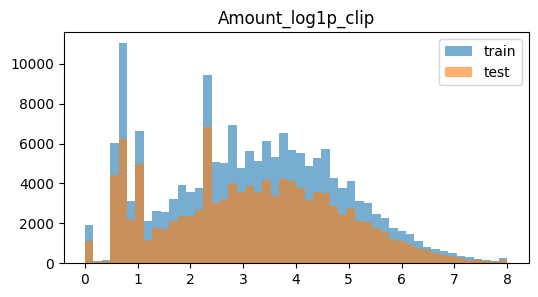

In [24]:
def quick_hist_compare(col):
    plt.figure(figsize=(6,3))
    plt.hist(train_f[col], bins=50, alpha=0.6, label="train")
    plt.hist(test_f[col], bins=50, alpha=0.6, label="test")
    plt.title(col)
    plt.legend()
    plt.show()

quick_hist_compare("hour")
quick_hist_compare("day")
quick_hist_compare("Amount_log1p_clip")

<br>

### **5. Threshold 튜닝 함수 (F1 최대화)**

In [ ]:
# Threshold 튜닝 유틸 (Validation에서 F1 최대 임계값 찾기)

In [ ]:
def find_best_threshold_by_f1(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    # precision_recall_curve는 thresholds 길이가 (n-1)라 맞춰줌
    f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-12)
    best_idx = np.nanargmax(f1_scores)

    best_thr = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_f1 = f1_scores[best_idx]
    best_p  = precisions[best_idx]
    best_r  = recalls[best_idx]
    return best_thr, best_f1, best_p, best_r

In [ ]:
def evaluate_at_threshold(y_true, y_proba, thr):
    y_pred = (y_proba >= thr).astype(int)
    return {
        "threshold": thr,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "confusion": confusion_matrix(y_true, y_pred)
    }

<br>

### **6. 베이스라인 (Logistic Regression + class_weight + 스케일링 + threshold)**

In [ ]:
# Train/Val split (Stratify 필수)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train class ratio:\n", (y_train.value_counts(normalize=True)*100).round(4))
print("Val class ratio:\n", (y_val.value_counts(normalize=True)*100).round(4))

Train class ratio:
 Class
0    99.7893
1     0.2107
Name: proportion, dtype: float64
Val class ratio:
 Class
0    99.7893
1     0.2107
Name: proportion, dtype: float64


In [ ]:
# Logistic Regression

In [ ]:
lr_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

In [ ]:
lr_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', RobustScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=4000,
                                    n_jobs=-1))])

In [ ]:
val_proba = lr_pipe.predict_proba(X_val)[:, 1]
ap = average_precision_score(y_val, val_proba)
best_thr, best_f1, best_p, best_r = find_best_threshold_by_f1(y_val, val_proba)

print(f"[LR] PR-AUC(AP): {ap:.6f}")
print(f"[LR] Best threshold: {best_thr:.6f} | F1: {best_f1:.6f} | P: {best_p:.6f} | R: {best_r:.6f}")

[LR] PR-AUC(AP): 0.728976
[LR] Best threshold: 0.999974 | F1: 0.819444 | P: 0.819444 | R: 0.819444


In [ ]:
metrics = evaluate_at_threshold(y_val, val_proba, best_thr)
print(metrics["confusion"])
print({k:v for k,v in metrics.items() if k!="confusion"})

[[34092    13]
 [   13    59]]
{'threshold': np.float64(0.9999742047052325), 'precision': 0.8194444444444444, 'recall': 0.8194444444444444, 'f1': 0.8194444444444444}


In [ ]:
# 1차 제출 파일 생성 (LR + best_thr)
# 전체 train으로 재학습 후 test 예측

In [ ]:
lr_pipe.fit(X, y)

Pipeline(steps=[('scaler', RobustScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=4000,
                                    n_jobs=-1))])

In [ ]:
test_proba = lr_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_thr).astype(int)

In [ ]:
submission = pd.DataFrame({"id": test_id, "Class": test_pred})
submission.to_csv("submission_lr_thr.csv", index=False)

submission.head()

,id,Class
0,170883,0
1,170884,0
2,170885,0
3,170886,0
4,170887,0


<br>

### **7. 3개 이상 모델 비교**

- LR / RF / LGBM

In [ ]:
# Stratified K-Fold 기반 모델 비교 프레임

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
def cv_eval_model_get_oof_proba(model, X, y, needs_scaler=False):
    oof_proba = np.zeros(len(y))
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        if needs_scaler:
            scaler = RobustScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_va_s = scaler.transform(X_va)
            model.fit(X_tr_s, y_tr)
            oof_proba[va_idx] = model.predict_proba(X_va_s)[:, 1]
        else:
            model.fit(X_tr, y_tr)
            oof_proba[va_idx] = model.predict_proba(X_va)[:, 1]

        if fold == 1:
            print(f"Fold {fold} done...")
    return oof_proba

<br>

In [ ]:
# 모델 생성

In [ ]:
# 1) LR

In [ ]:
lr_model = LogisticRegression(max_iter=4000, class_weight="balanced", n_jobs=-1)

In [ ]:
# 2) RF (class_weight로 불균형 반영)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=1,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

In [ ]:
# 3) LightGBM (불균형 반영 is_unbalance 또는 scale_pos_weight)

In [ ]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.02,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    is_unbalance=True
)

<br>

In [ ]:
# OOF 기반으로 모델별 최적 threshold / F1 계산

In [ ]:
results = []

In [ ]:
# 1) LR (스케일 필요)

In [ ]:
lr_oof = cv_eval_model_get_oof_proba(lr_model, X, y, needs_scaler=True)
lr_thr, lr_f1, lr_p, lr_r = find_best_threshold_by_f1(y, lr_oof)
results.append(["LogReg(balanced)+Robust", lr_f1, lr_thr, average_precision_score(y, lr_oof)])

Fold 1 done...


In [ ]:
# 2) RF (스케일 불필요)

In [ ]:
rf_oof = cv_eval_model_get_oof_proba(rf_model, X, y, needs_scaler=False)
rf_thr, rf_f1, rf_p, rf_r = find_best_threshold_by_f1(y, rf_oof)
results.append(["RandomForest(balanced)", rf_f1, rf_thr, average_precision_score(y, rf_oof)])

Fold 1 done...


In [ ]:
# 3) LGBM

In [ ]:
lgb_oof = cv_eval_model_get_oof_proba(lgb_model, X, y, needs_scaler=False)
lgb_thr, lgb_f1, lgb_p, lgb_r = find_best_threshold_by_f1(y, lgb_oof)
results.append(["LightGBM(is_unbalance)", lgb_f1, lgb_thr, average_precision_score(y, lgb_oof)])

Fold 1 done...


In [ ]:
res_df = pd.DataFrame(results, columns=["model", "oof_f1(best)", "best_thr", "oof_PR-AUC(AP)"])
res_df.sort_values("oof_f1(best)", ascending=False)

,model,oof_f1(best),best_thr,oof_PR-AUC(AP)
2,LightGBM(is_unbalance),0.886628,0.580517,0.870984
1,RandomForest(balanced),0.884672,0.327500,0.868382
0,LogReg(balanced)+Robust,0.817175,0.999963,0.729967


<br>

### **8. LightGBM 튜닝(가성비) + Early Stopping**

In [ ]:
# LGBM Holdout 기반 간단 튜닝(early stopping)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale_pos_weight = (neg/pos) 권장값 (불균형 비율 기반)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / max(pos, 1)

lgb_tuned = lgb.LGBMClassifier(
    n_estimators=10000,
    learning_rate=0.01,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=spw
)

In [ ]:
lgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="binary_logloss",
    callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)]
)

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.01, n_estimators=10000,
               num_leaves=64, random_state=42, reg_lambda=1.0,
               scale_pos_weight=np.float64(473.6736111111111), subsample=0.8)

In [ ]:
val_proba = lgb_tuned.predict_proba(X_val)[:, 1]
best_thr, best_f1, best_p, best_r = find_best_threshold_by_f1(y_val, val_proba)

print(f"[LGBM tuned] best_iter: {lgb_tuned.best_iteration_}")
print(f"[LGBM tuned] Best thr: {best_thr:.6f} | F1: {best_f1:.6f} | P:{best_p:.6f} | R:{best_r:.6f}")
print("PR-AUC(AP):", average_precision_score(y_val, val_proba))

[LGBM tuned] best_iter: 1105
[LGBM tuned] Best thr: 0.533179 | F1: 0.919708 | P:0.969231 | R:0.875000
PR-AUC(AP): 0.8801365254406123


In [ ]:
# tuned LGBM 제출 파일
# 전체 데이터로 재학습(베스트 이터레이션 사용)

In [ ]:
final_lgb = lgb.LGBMClassifier(**lgb_tuned.get_params())
final_lgb.set_params(n_estimators=lgb_tuned.best_iteration_)

final_lgb.fit(X, y)

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.01, n_estimators=1105,
               num_leaves=64, random_state=42, reg_lambda=1.0,
               scale_pos_weight=np.float64(473.6736111111111), subsample=0.8)

In [ ]:
test_proba = final_lgb.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_thr).astype(int)

submission = pd.DataFrame({"id": test_id, "Class": test_pred})
submission.to_csv("submission_lgb_tuned.csv", index=False)
submission.head()

,id,Class
0,170883,0
1,170884,0
2,170885,0
3,170886,0
4,170887,0


<br>

### **9. 앙상블 전략**

- Soft Voting (LR + LGBM 조합 좋은 편)

- OOF로 threshold까지 최적화하면 앙상블이 이득일 것으로 예상

In [ ]:
# OOF 기반 Soft Voting (LR + LGBM)
# 확률 평균 후 threshold 최적화

In [ ]:
ens_oof = 0.5 * lr_oof + 0.5 * lgb_oof
ens_thr, ens_f1, ens_p, ens_r = find_best_threshold_by_f1(y, ens_oof)

print(f"[Ensemble OOF] Best thr: {ens_thr:.6f} | F1: {ens_f1:.6f} | P:{ens_p:.6f} | R:{ens_r:.6f}")
print("[Ensemble OOF] PR-AUC(AP):", average_precision_score(y, ens_oof))

[Ensemble OOF] Best thr: 0.772957 | F1: 0.887918 | P:0.932722 | R:0.847222
[Ensemble OOF] PR-AUC(AP): 0.8705213720076809


In [ ]:
# Soft Voting 제출 (최적 thr 적용)
# LR 학습(스케일링 포함) + LGBM 학습 후, test proba 평균

In [ ]:
# LR 파이프 재학습
lr_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(max_iter=4000, class_weight="balanced", n_jobs=-1))
])
lr_pipe.fit(X, y)

Pipeline(steps=[('scaler', RobustScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=4000,
                                    n_jobs=-1))])

In [ ]:
# LGBM도 학습
final_lgb.fit(X, y)

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.01, n_estimators=1105,
               num_leaves=64, random_state=42, reg_lambda=1.0,
               scale_pos_weight=np.float64(473.6736111111111), subsample=0.8)

In [ ]:
lr_test_proba  = lr_pipe.predict_proba(X_test)[:, 1]
lgb_test_proba = final_lgb.predict_proba(X_test)[:, 1]

ens_test_proba = 0.5 * lr_test_proba + 0.5 * lgb_test_proba
ens_test_pred  = (ens_test_proba >= ens_thr).astype(int)

submission = pd.DataFrame({"id": test_id, "Class": ens_test_pred})
submission.to_csv("submission_ensemble_lr_lgb.csv", index=False)
submission.head()

,id,Class
0,170883,0
1,170884,0
2,170885,0
3,170886,0
4,170887,0


<br>

In [ ]:
# (1) 불균형 비율
neg = int((y == 0).sum())
pos = int((y == 1).sum())
scale_pos_weight = neg / max(pos, 1)
print("neg:", neg, "pos:", pos, "scale_pos_weight:", scale_pos_weight)

# (2) CV 설정
N_SPLITS = 5
skf5 = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# (3) 학습 컨트롤
EARLY_STOPPING_ROUNDS = 200
VERBOSE_EVAL = False

# (4) 멀티 시드 앙상블
SEEDS = [42, 202]

print("N_SPLITS:", N_SPLITS, "| SEEDS:", SEEDS)

neg: 170523 pos: 360 scale_pos_weight: 473.675
N_SPLITS: 5 | SEEDS: [42, 202]


In [ ]:
# 모델 파라미터 정의

In [ ]:
# 1) LGBM - 규제 강(일반화 강화)
lgb_params_strong = dict(
    n_estimators=20000,
    learning_rate=0.01,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=150,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=25.0,
    min_split_gain=0.05,
    max_bin=127,
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

In [ ]:
# 2) LGBM - 규제 중(균형형)
lgb_params_medium = dict(
    n_estimators=20000,
    learning_rate=0.015,
    num_leaves=47,
    max_depth=-1,
    min_child_samples=80,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.3,
    reg_lambda=10.0,
    min_split_gain=0.02,
    max_bin=255,
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

In [ ]:
# 3) LGBM - 규제 약(공격형, 과하지 않게)
lgb_params_weak = dict(
    n_estimators=20000,
    learning_rate=0.02,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=3.0,
    min_split_gain=0.0,
    max_bin=255,
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

In [ ]:
# OOF & Test proba 생성 함수

In [ ]:
def get_oof_and_test_proba(model_name, params, X, y, X_test, seeds, skf):
    """
    model_name: "LGBM_*" or "XGB_*"
    params: dict
    seeds: list of seeds
    returns:
      oof_proba_avg: (n_train,)
      test_proba_avg: (n_test,)
    """
    n_train = len(y)
    n_test = X_test.shape[0]

    oof_all = []
    test_all = []

    for seed in seeds:
        # seed 반영
        p = params.copy()
        p["random_state"] = seed

        oof = np.zeros(n_train, dtype=float)
        test_fold_preds = []

        for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
            y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

            if model_name.startswith("LGBM"):
                model = lgb.LGBMClassifier(**p)
                model.fit(
                    X_tr, y_tr,
                    eval_set=[(X_va, y_va)],
                    eval_metric="binary_logloss",
                    callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=VERBOSE_EVAL)]
                )
                oof[va_idx] = model.predict_proba(X_va)[:, 1]
                test_fold_preds.append(model.predict_proba(X_test)[:, 1])

            elif model_name.startswith("XGB"):
                model = xgb.XGBClassifier(**p)
                model.fit(
                    X_tr, y_tr,
                    eval_set=[(X_va, y_va)],
                    verbose=False,
                    early_stopping_rounds=EARLY_STOPPING_ROUNDS
                )
                oof[va_idx] = model.predict_proba(X_va)[:, 1]
                test_fold_preds.append(model.predict_proba(X_test)[:, 1])

            else:
                raise ValueError("Unknown model_name")

            if fold == 1:
                print(f"[{model_name} | seed={seed}] fold {fold} started...")

        # fold별 test 예측 평균
        test_pred_seed = np.mean(test_fold_preds, axis=0)

        oof_all.append(oof)
        test_all.append(test_pred_seed)

        # 간단 로그
        ap = average_precision_score(y, oof)
        print(f"[{model_name} | seed={seed}] OOF PR-AUC(AP): {ap:.6f}")

    # seed 평균
    oof_proba_avg = np.mean(oof_all, axis=0)
    test_proba_avg = np.mean(test_all, axis=0)

    ap_avg = average_precision_score(y, oof_proba_avg)
    print(f"\n[{model_name}] SEED-AVG OOF PR-AUC(AP): {ap_avg:.6f}\n")

    return oof_proba_avg, test_proba_avg

In [ ]:
# 각 모델 OOF/Test proba 생성

In [ ]:
MODEL_SPECS = [
    ("LGBM_strong", lgb_params_strong),
    ("LGBM_medium", lgb_params_medium),
    ("LGBM_weak",   lgb_params_weak),
]

print("Model specs:", [m[0] for m in MODEL_SPECS])

Model specs: ['LGBM_strong', 'LGBM_medium', 'LGBM_weak']


In [ ]:
oof_dict = {}
test_dict = {}

for model_name, params in MODEL_SPECS:
    oof_proba, test_proba = get_oof_and_test_proba(
        model_name=model_name,
        params=params,
        X=X, y=y, X_test=X_test,
        seeds=SEEDS,
        skf=skf5
    )
    oof_dict[model_name] = oof_proba
    test_dict[model_name] = test_proba

print("DONE. Models:", list(oof_dict.keys()))

[LGBM_strong | seed=42] fold 1 started...
[LGBM_strong | seed=42] OOF PR-AUC(AP): 0.437537
[LGBM_strong | seed=202] fold 1 started...
[LGBM_strong | seed=202] OOF PR-AUC(AP): 0.740902

[LGBM_strong] SEED-AVG OOF PR-AUC(AP): 0.681420

[LGBM_medium | seed=42] fold 1 started...
[LGBM_medium | seed=42] OOF PR-AUC(AP): 0.876929
[LGBM_medium | seed=202] fold 1 started...
[LGBM_medium | seed=202] OOF PR-AUC(AP): 0.877949

[LGBM_medium] SEED-AVG OOF PR-AUC(AP): 0.877624

[LGBM_weak | seed=42] fold 1 started...
[LGBM_weak | seed=42] OOF PR-AUC(AP): 0.870271
[LGBM_weak | seed=202] fold 1 started...
[LGBM_weak | seed=202] OOF PR-AUC(AP): 0.868848

[LGBM_weak] SEED-AVG OOF PR-AUC(AP): 0.870605

DONE. Models: ['LGBM_strong', 'LGBM_medium', 'LGBM_weak']


In [ ]:
# 단순 평균 앙상블

In [ ]:
ensemble_models = list(oof_dict.keys())
oof_ens = np.mean([oof_dict[m] for m in ensemble_models], axis=0)
test_ens = np.mean([test_dict[m] for m in ensemble_models], axis=0)

ens_thr, ens_f1, ens_p, ens_r = find_best_threshold_by_f1(y, oof_ens)
ens_ap = average_precision_score(y, oof_ens)

print("[Ensemble Mean] OOF PR-AUC(AP):", round(ens_ap, 6))
print("[Ensemble Mean] Best thr:", float(ens_thr))
print("[Ensemble Mean] F1:", float(ens_f1), "| P:", float(ens_p), "| R:", float(ens_r))

[Ensemble Mean] OOF PR-AUC(AP): 0.848846
[Ensemble Mean] Best thr: 0.5406695856284821
[Ensemble Mean] F1: 0.8866571018646369 | P: 0.9169139465875371 | R: 0.8583333333333333


In [ ]:
# 가중치 탐색(가성비)

In [ ]:
# LGBM 3종 가중치 탐색
names = ["LGBM_strong", "LGBM_medium", "LGBM_weak"]

In [ ]:
best = None
cands = []

# 후보 가중치(합이 1이 되도록)
for wS in [0.2, 0.3, 0.4]:
    for wM in [0.3, 0.4, 0.5]:
        wW = 1.0 - (wS + wM)
        if wW < 0.0:
            continue
        cands.append((wS, wM, wW))

In [ ]:
for (wS, wM, wW) in cands:
    oof_w = (
        wS * oof_dict["LGBM_strong"] +
        wM * oof_dict["LGBM_medium"] +
        wW * oof_dict["LGBM_weak"]
    )
    thr, f1v, pv, rv = find_best_threshold_by_f1(y, oof_w)
    apv = average_precision_score(y, oof_w)

    if (best is None) or (f1v > best["f1"]):
        best = dict(weights=(wS, wM, wW), thr=thr, f1=f1v, p=pv, r=rv, ap=apv)

print("Best by OOF-F1 (LGBM only):")
print("weights (strong, medium, weak) =", best["weights"])
print("OOF PR-AUC(AP)                =", float(best["ap"]))
print("Best thr                      =", float(best["thr"]))
print("F1 / P / R                    =", float(best["f1"]), float(best["p"]), float(best["r"]))

Best by OOF-F1 (LGBM only):
weights (strong, medium, weak) = (0.3, 0.3, 0.4)
OOF PR-AUC(AP)                = 0.8510422373264903
Best thr                      = 0.5222947282096636
F1 / P / R                    = 0.8866571018646369 0.9169139465875371 0.8583333333333333
